Spalten nach dem Einlesen: ['mg * L^-1', 'min', 'min.1', 'mAU*s']


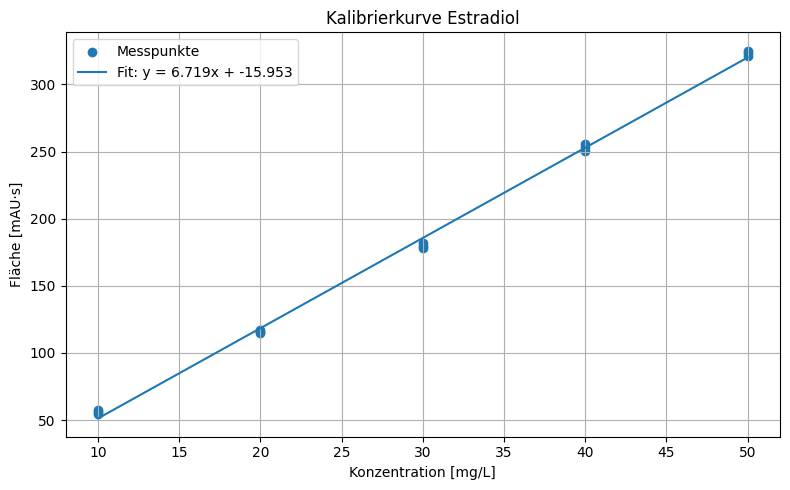


--- Lineare Regression ---
Steigung m        = 6.719006
Achsenabschnitt b = -15.953445
y = 6.719006x + -15.953445
R² = 0.998159
s_y = 4.383214
n = 15
------------------------------------------------------------
konz = [10. 10. 10. 20. 20. 20. 30. 30. 30. 40. 40. 40. 50. 50. 50.]
------------------------------------------------------------
m_WirkstoffPulver = 1.826829 mg
s_c = 13.505403 mg/L
------------------------------------------------------------
Mittelwert y_Fläche = 187.1690866666667
c_real = 30.231000 mg/L
s_creal = 0.369641 mg/L
m_real = 1.511550 mg
s_mreal = 0.018482 mg


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. Excel-Datei laden
# ---------------------------------------------------------

datei = "/Users/sascha0404/Documents/UNI/Chemie/5. Semester/PR Instrumentalanalytisches Praktikum/HPLC/Notizen.xlsx"

# Wir lesen den Block Y:AC ein
df = pd.read_excel(
    datei,
    sheet_name="Tabelle1",
    header=6,        # Zeile mit den Einheiten: 'mg * L^-1', 'mAU*s', ...
    usecols="Y:AB"
)

# Spaltennamen säubern
df.columns = df.columns.astype(str).str.strip()

print("Spalten nach dem Einlesen:", df.columns.tolist())
# -> ['mg * L^-1', 'min', 'min.1', 'mAU*s', 'mAU']

# Falls die erste Datenzeile noch Müll ist, könnte man df = df.iloc[1:] machen.
# In deinem Screenshot sehen die Zeilen unter den Einheiten aber schon wie Messwerte aus,
# daher lassen wir alles drin.

# ---------------------------------------------------------
# 2. Spalten für Konzentration & Fläche verwenden
# ---------------------------------------------------------

konz = pd.to_numeric(df["mg * L^-1"], errors="coerce")
flaeche = pd.to_numeric(df["mAU*s"], errors="coerce")

# Eventuelle NaNs (z.B. leere Zeilen) entfernen
mask = ~konz.isna() & ~flaeche.isna()
konz = konz[mask].values
flaeche = flaeche[mask].values

# ---------------------------------------------------------
# 3. Plot erstellen
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.scatter(konz, flaeche, label="Messpunkte")

# Lineare Regression (Kalibriergerade)
m, b = np.polyfit(konz, flaeche, 1)
x_fit = np.linspace(min(konz), max(konz), 100)
y_fit = m * x_fit + b

# Vorhergesagte y-Werte
y_pred = m * konz + b

# Mittelwert von x,y
y_mean = np.mean(flaeche)
x_mean = np.mean(konz)

# Summe der Quadrate
SS_res = np.sum((flaeche - y_pred) ** 2)
SS_tot = np.sum((flaeche - y_mean) ** 2)

# R²
R2 = 1 - (SS_res / SS_tot)

plt.plot(x_fit, y_fit, label=f"Fit: y = {m:.3f}x + {b:.3f}")

plt.title("Kalibrierkurve Estradiol")
plt.xlabel("Konzentration [mg/L]")
plt.ylabel("Fläche [mAU·s]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#Standardabweichung s_y der Regressionsgerade
# Vorhergesagte y-Werte
y_pred = m * konz + b

# Anzahl Punkte
n = len(konz)

# Residuenquadratsumme
SS_res = np.sum((flaeche - y_pred)**2)

# Standardabweichung der Regression
s_y = np.sqrt(SS_res / (n - 2))



#Berechnung de theoretischen Konzentration im 50mL Maßkolben
m_Tablette = 0.0820 #g
m_Wirkstoff = 0.002 #g
m_Pulver = 0.0749 #g
V = 0.05 #L

m_WirkstoffPulver = (m_Wirkstoff/m_Tablette) * m_Pulver * 1000
c_TheorieWirkstoff = (m_WirkstoffPulver / V) #Die Konzentration bezieht sich auf die Wirkstoffeinwaage

s_c = s_m *(m_WirkstoffPulver / V)

#Berechnung der tatsächlichen Masse und KOnzentration in der Lösung aus der Regressionsgerade
Fläche = [188.59358, 188.33891, 184.57477]
y_Fläche = np.mean(Fläche)

c_real = (y_Fläche + 15.953) / 6.719
m_real = c_real * V

s_creal = (s_y/m) * np.sqrt((1/n)+(y_mean)**2/(m**2 * np.sum((konz - x_mean)**2)))
s_mreal = s_creal * V



# ---------------------------------------------------------
# 4. Fit-Parameter ausgeben
# ---------------------------------------------------------

print("\n--- Lineare Regression ---")
print(f"Steigung m        = {m:.6f}")
print(f"Achsenabschnitt b = {b:.6f}")
print(f"y = {m:.6f}x + {b:.6f}")
print(f"R² = {R2:.6f}")
print(f"s_y = {s_y:.6f}")
print("n =", n)

print("-" * 60)
print("konz =", konz)

print("-" * 60)

print(f"m_WirkstoffPulver = {m_WirkstoffPulver:.6f} mg")
print(f"s_c = {s_c:.6f} mg/L")

print("-" * 60)

print(f"Mittelwert y_Fläche = {y_Fläche}")
print(f"c_real = {c_real:.6f} mg/L")
print(f"s_creal = {s_creal:.6f} mg/L")
print(f"m_real = {m_real:.6f} mg")
print(f"s_mreal = {s_mreal:.6f} mg")